In [54]:
from dace_query.sun import Sun
from dace_query.spectroscopy import Spectroscopy

from astropy.io import fits
from astropy import constants as const
from astropy.time import Time
from astropy.timeseries import LombScargle

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import date, timedelta, datetime

from scipy.optimize import curve_fit
from scipy.interpolate import RegularGridInterpolator
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import re  # find patter in string
from tqdm import tqdm  # progress bar
import logging  # to avoid printing too many warnings
from joblib import Parallel, delayed  # paralellization

import tools as t

In [5]:
# get RV data of the Sun
data_original = Sun.query_database(output_format="pandas", limit=200000)
to_keep = data_original.spectro_drs_qc == 1
data = data_original[to_keep]

In [6]:
# extract time and radial velocity from the data
time   = data.obj_date_bjd  # BJD
rv_sun = data.spectro_ccf_rv  # m/s

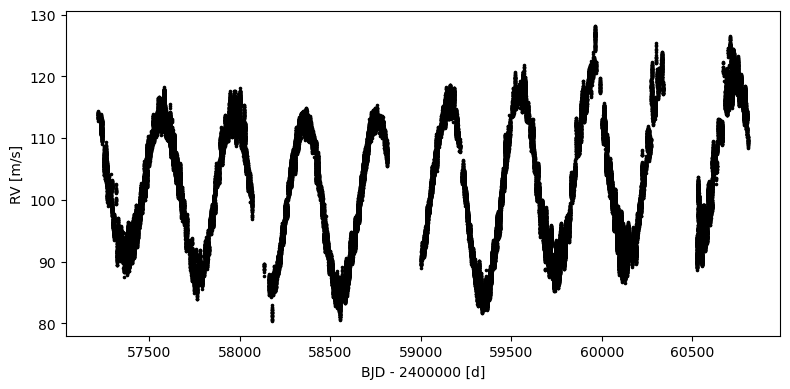

In [7]:
# plot the raw radial velocities, in the Solar System barycenter rest frame
plt.figure(figsize=(8, 4))
plt.scatter(time, rv_sun, marker='.', s=10, color='k')
plt.xlabel('BJD - 2400000 [d]')
plt.ylabel('RV [m/s]')
plt.tight_layout()

In [8]:
# perform fit
# initial guess for P is the synodic period of Jupiter
fit = curve_fit(t.RV_jup, time, rv_sun, p0=[1, 1, 398, 1, 1])
A_0 , A_1, P, phi, C = fit[0]

In [9]:
# create time array to plot the fit as a function of it
time_fit = np.linspace(min(time), max(time), 500)
# calculate the sinusoidal function for the time array
rv_sun_fit = np.array([])
for i in time_fit:
    y = t.RV_jup(i, A_0, A_1, P, phi, C)
    rv_sun_fit = np.append(rv_sun_fit, y)

In [10]:
# calculate residuals
res = rv_sun - t.RV_jup(time, A_0 , A_1, P, phi, C)

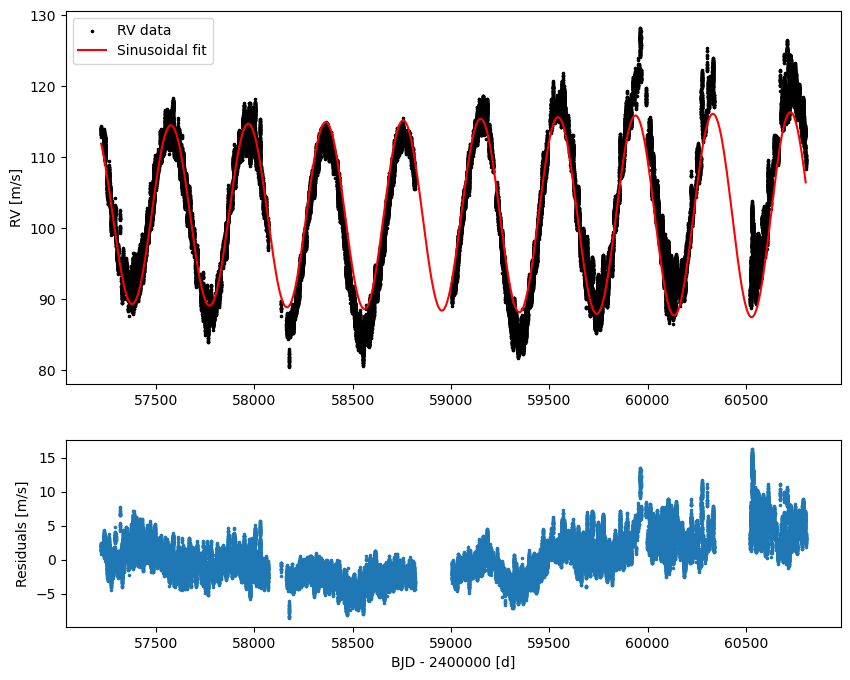

In [11]:
# plot data and fit
fig, axs = plt.subplots(2, 1, figsize=(10, 8), height_ratios=[2, 1])
axs[0].scatter(time, rv_sun, marker='.', s=10, color='k', label='RV data')
axs[0].plot(time_fit, rv_sun_fit, color='red', label='Sinusoidal fit')
axs[0].set_ylabel('RV [m/s]')
axs[0].legend()
axs[1].scatter(time, res, marker='.', s=10)
axs[1].set_xlabel('BJD - 2400000 [d]')
axs[1].set_ylabel('Residuals [m/s]')
plt.show()

## Spectra

In [12]:
# get data corresponding to 2017 and 2018
# maximum one file per day
data_spec = data[data['date_night'] < '2019']
data_spec = data_spec['2017' < data_spec['date_night']].sort_values('date_night')
data_spec = data_spec.sort_values('obj_date_bjd')
dates_RV = data_spec['date_night'].to_numpy()
files_RV = data_spec['file_rootpath'].to_numpy()
# define the path of the directory where data is saved
path = '../data/dace_sun/'
dates_RV

array(['2017-01-02', '2017-01-02', '2017-01-02', ..., '2018-12-31',
       '2018-12-31', '2018-12-31'], shape=(23133,), dtype=object)

In [13]:
# get absorption bands
bands = np.genfromtxt('../data/bands.txt', dtype=None, encoding=None, names=True, delimiter=',')

In [14]:
# extract data from saved files
# example for one file
filename = path + '2017-2018/2017-01-06/r.HARPN.2017-01-06T10-14-37.087_S1D_A.fits'
s1d = fits.getdata(filename, 1)
wl = s1d['wavelength_air']  # angstrom
s1d.columns

ColDefs(
    name = 'wavelength'; format = '1D'; unit = 'angstrom'
    name = 'wavelength_air'; format = '1D'; unit = 'angstrom'
    name = 'flux'; format = '1D'; unit = 'e-'
    name = 'error'; format = '1D'; unit = 'e-'
    name = 'quality'; format = '1J'
)

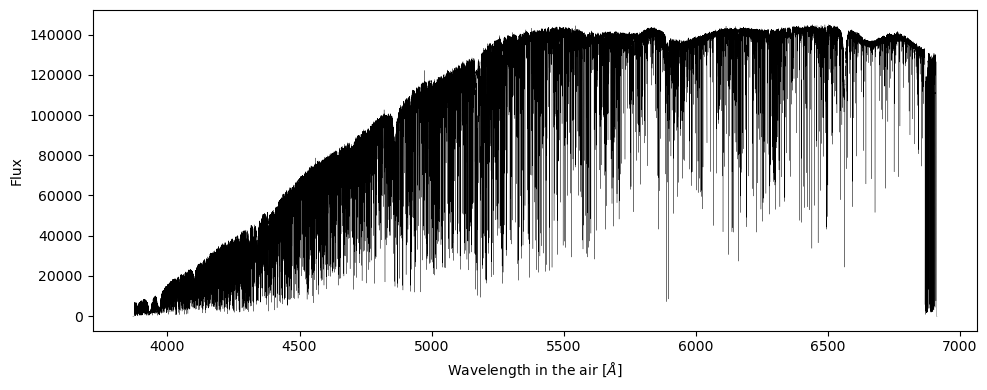

In [15]:
# plot spectrum
plt.figure(figsize=(10, 4))
plt.plot(wl, s1d['flux'], linewidth=.2, color='k')
plt.xlabel(r'Wavelength in the air [$\AA$]')
plt.ylabel('Flux')
plt.tight_layout()

In [16]:
# iterate over saved files from 2017 to 2018
# save names (observation dates) of the files
dates_spec = []
for entry in os.scandir(path + '2017-2018'):
    if entry.name != 'spectra.txt':
        dates_spec.append(entry.name)

In [17]:
dates_spec = sorted(dates_spec, key=lambda d: datetime.strptime(d, "%Y-%m-%d"))

print(dates_spec)

['2017-01-06', '2017-01-09', '2017-01-15', '2017-01-16', '2017-01-18', '2017-01-19', '2017-01-21', '2017-01-23', '2017-01-24', '2017-01-25', '2017-02-05', '2017-02-06', '2017-02-08', '2017-02-13', '2017-02-20', '2017-02-23', '2017-02-25', '2017-02-26', '2017-02-27', '2017-02-28', '2017-03-01', '2017-03-02', '2017-03-03', '2017-03-04', '2017-03-05', '2017-03-07', '2017-03-08', '2017-03-09', '2017-03-12', '2017-03-13', '2017-03-16', '2017-03-23', '2017-03-24', '2017-03-27', '2017-03-28', '2017-04-01', '2017-04-02', '2017-04-05', '2017-04-06', '2017-04-09', '2017-04-12', '2017-04-13', '2017-04-14', '2017-04-16', '2017-04-17', '2017-04-18', '2017-04-21', '2017-04-23', '2017-04-24', '2017-04-30', '2017-05-02', '2017-05-03', '2017-05-05', '2017-05-07', '2017-05-13', '2017-05-18', '2017-05-19', '2017-05-21', '2017-05-22', '2017-05-23', '2017-05-24', '2017-05-25', '2017-05-26', '2017-05-27', '2017-05-28', '2017-05-29', '2017-05-30', '2017-05-31', '2017-06-01', '2017-06-02', '2017-06-03', '2017

In [18]:
# make a list of the available files that end by A.fits
dates_files = np.array(sorted([i.name for i in list(os.scandir(path + '2017-2018'))]))
files_list = []
for d in dates_files:
    date_path = f'{path}2017-2018/{d}/'
    files = os.scandir(date_path)
    files = list(files)
    files = [d + '/' + i.name for i in files]
    files_list.extend(files)
files_list = [s for s in files_list if s.endswith('A.fits')]
files_list = np.array(files_list)
len(files_list)

596

In [19]:
# save spectra in matrix rows
# the row i from spectra contains the spectrum from the file i from files_list
spectra = []
err = []
for f in files_list:
    file_path = path + '2017-2018/' + f
    hdul = fits.open(file_path)
    spectra.append(hdul[1].data['flux'])
    err.append(hdul[1].data['error'])
            
spectra = np.array(spectra)
err = np.array(err)
print(spectra.shape, err.shape)

(596, 212207) (596, 212207)


In [51]:
# get corresponding RV data
# extract datetime from file names (file_rootpath) in data_spec
pattern = re.compile(r"\d{4}-\d{2}-\d{2}T\d{2}-\d{2}-\d{2}\.\d+")

dict1 = {}  # datetime string: RV file name
for sequence in files_list:
    time_str = t.extract_pattern(sequence, pattern)
    if time_str:
        dict1[time_str] = sequence

measure_times = sorted(list(dict1.keys()))
print(len(measure_times))

# find rows in data_spec (dataframe that contains RV) that have measures at the time indicated in the downloaded files
matches = []  # contains tuples of the form: (name_of_spectrum_file, name_of_RV_file)

for sequence in files_RV:
    time_str = t.extract_pattern(sequence, pattern)
    if time_str in dict1:
        matches.append((dict1[time_str], sequence))
matches = np.array(matches)
times = np.array([datetime.strptime(i, '%Y-%m-%dT%H-%M-%S.%f') for i in list(dict1.keys())])
times_jd = np.array([Time(i).jd for i in times])

596


In [21]:
# RV data from data_spec recovered from the rows where the column 'file_rootpath' is in the list of matches
RV_list = data_spec[data_spec['file_rootpath'].isin(matches[:, 1])]['spectro_ccf_rv'].to_numpy()
len(RV_list)

596

In [22]:
# calculate lambda_corr for each day
lambda_corr  = []
for rv in RV_list:
    lambda_corr.append(wl * (1 - rv / 3e8))  # corrected wavelength in Angstrom
lambda_corr = np.array(lambda_corr)
lambda_mean = np.array([np.mean(i) for i in lambda_corr])  # mean wavelength each day

In [23]:
# interpolation to a common reference grid
# choose a reference wavelength grid
wmin = max(w.min() for w in lambda_corr)  # max to ensure all spectra cover the chosen range
wmax = min(w.max() for w in lambda_corr)  # min to ensure all spectra cover the chosen range
print(f'New wavelength range: {round(wmin, 1)} to {round(wmax, 1)} angstrom.')
wl_ref = np.linspace(wmin, wmax, len(wl))

# interpolate
resampled_flux = []

for wave, flux in zip(lambda_corr, spectra):
    interp_flux = np.interp(wl_ref, wave, flux)  # to have nans for values outside wl_ref range: left=np.nan, right=np.nan
    resampled_flux.append(interp_flux)

spectra_matrix = np.array(resampled_flux)

New wavelength range: 3868.9 to 6913.0 angstrom.


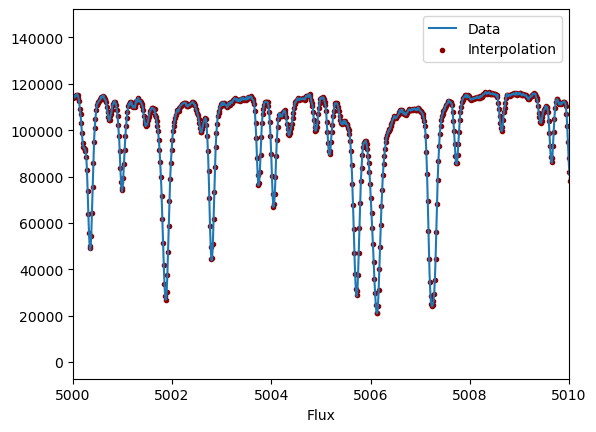

In [33]:
# check interpolation
wl_test = lambda_corr[0]
flux_test = spectra[0]
interp_test = np.interp(wl_ref, wl_test, flux_test)

plt.plot(wl_test, flux_test, label='Data')
plt.scatter(wl_ref, interp_test, color='darkred', marker='.', label='Interpolation')
plt.xlim(5000, 5010)
plt.xlabel('Wavelength')
plt.xlabel('Flux')
plt.legend()
plt.show()

In [24]:
# apply double centering
spectra_centered = t.double_centering(spectra)

# centering over t: substract the mean over time at every wavelength
#spectra_centered = spectra_matrix - np.mean(spectra_matrix, axis=1, keepdims=True)

In [25]:
# apply PCA to spectra matrix
n_components = 40
pca_flux = PCA(n_components=n_components)  # create PCA object
pcs  = pca_flux.fit_transform(spectra_centered)  # fit the model with spectra_centered and apply the dimensionality reduction
var  = pca_flux.explained_variance_ratio_
print(f'Variance explained by the {n_components} components:', var)  # how much information (variance) can be attributed to each of the principal components

Variance explained by the 40 components: [9.44644828e-01 4.08167891e-02 6.15298961e-03 3.10690653e-03
 1.48010059e-03 2.45075123e-04 1.32538443e-04 1.10482137e-04
 7.59841944e-05 6.80265655e-05 5.84742822e-05 4.22580387e-05
 3.44197011e-05 2.89885999e-05 2.36876182e-05 2.19893894e-05
 1.71679415e-05 1.62736798e-05 1.38626950e-05 1.26010425e-05
 1.23456759e-05 1.16470176e-05 1.06579561e-05 1.02193404e-05
 9.81392112e-06 9.75580622e-06 9.51067242e-06 9.23068833e-06
 9.07870989e-06 8.78194205e-06 8.62495444e-06 8.39271607e-06
 8.26208644e-06 8.24739967e-06 8.13251981e-06 8.02271648e-06
 7.97631280e-06 7.87753174e-06 7.71606768e-06 7.68767183e-06]


In [27]:
# component significance
spectra_noisy = spectra_centered + np.random.normal(0, err)
comps = pca_flux.components_

pca_noisy = PCA(n_components=n_components, svd_solver="randomized")
pca_noisy.fit(spectra_noisy)

comps_noisy = pca_noisy.components_

simi = comps @ comps_noisy.T

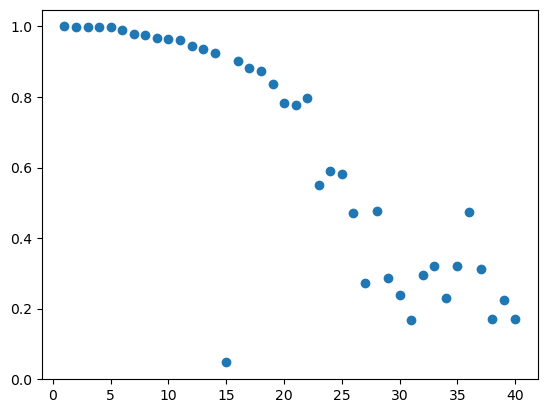

In [ ]:
plt.scatter(np.linspace(1, n_components, n_components), np.amax(simi, axis=1))
plt.show()

In [26]:
# multiple realizations

n_realizations = 20

# Optional but strongly recommended
spectra_centered = spectra_centered.astype(np.float32)
err = err.astype(np.float32)
comps = pca_flux.components_.astype(np.float32)

# Preallocate result array (small, safe)
simi_all = np.empty((n_realizations, n_components, n_components), dtype=np.float32)

for i in tqdm(range(n_realizations)):
    spectra_noisy = spectra_centered + np.random.normal(0, err)

    pca_noisy = PCA(n_components=n_components, svd_solver="randomized")
    pca_noisy.fit(spectra_noisy)

    comps_noisy = pca_noisy.components_

    simi_all[i] = comps @ comps_noisy.T

100%|██████████| 20/20 [06:53<00:00, 20.69s/it]


In [28]:
maxes = np.array([np.amax(s, axis=1) for s in simi_all])  # max of each row of each realization
mean_maxes = np.array([(np.average(s), np.std(s)) for s in maxes.T])  # list of max mean and std for each PC: [(max_avg_1, max_std_1), (max_avg_2, max_std_2), ..., (max_avg_n, max_std_n)]

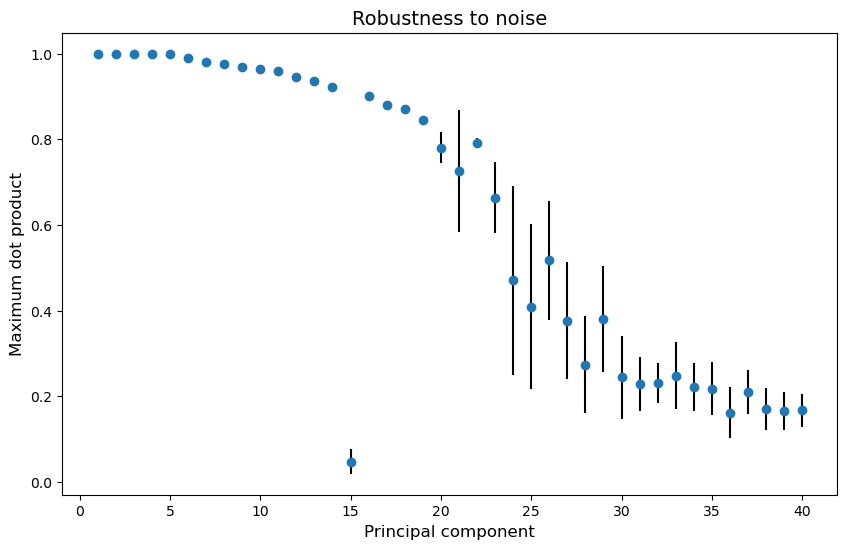

In [30]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(np.linspace(1, n_components, n_components), mean_maxes[:, 0], mean_maxes[:, 1], fmt='o', ecolor='k')
ax.set_title('Robustness to noise', size=14)
ax.set_xlabel('Principal component', size=12)
ax.set_ylabel('Maximum dot product', size=12)
plt.show()

In [73]:
# Fourier transform (Lomb-Scargle)

periodograms = [LombScargle(times_jd, pcs[:, i]).autopower() for i in range(n_components)]

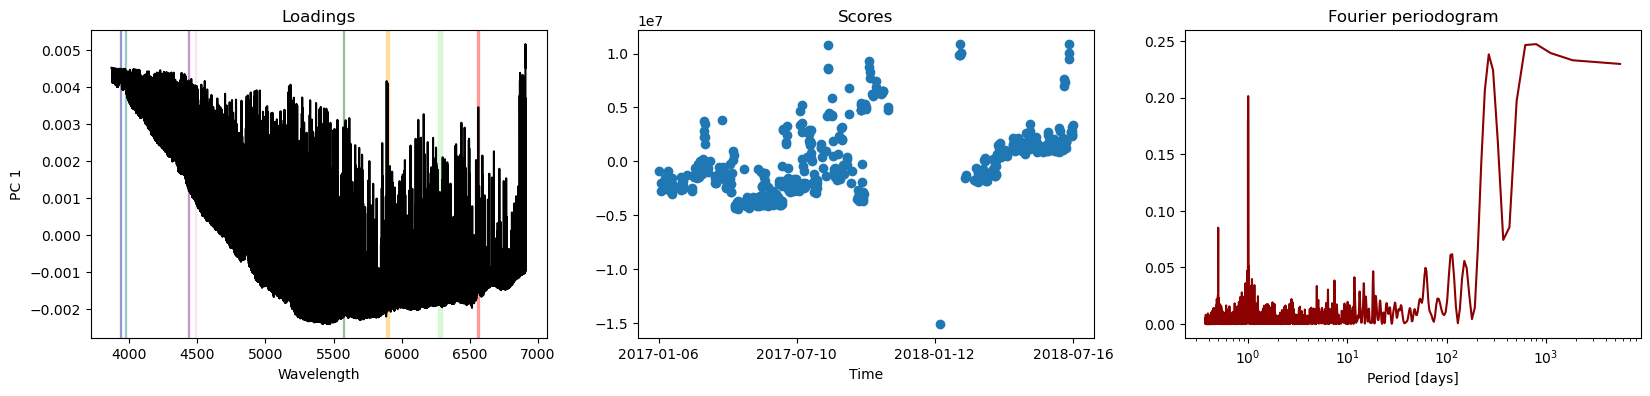

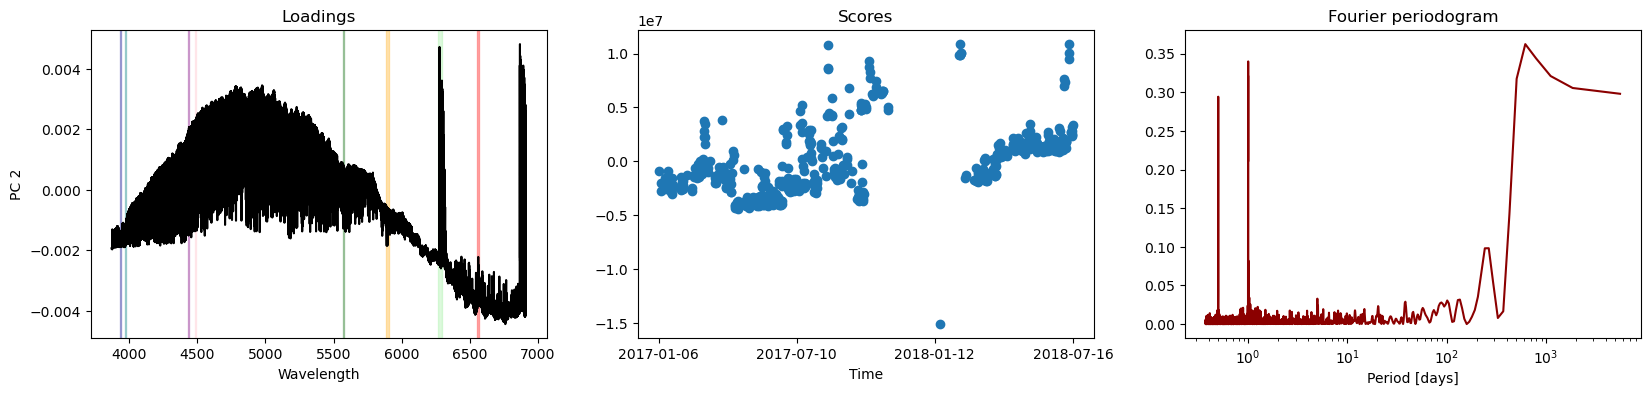

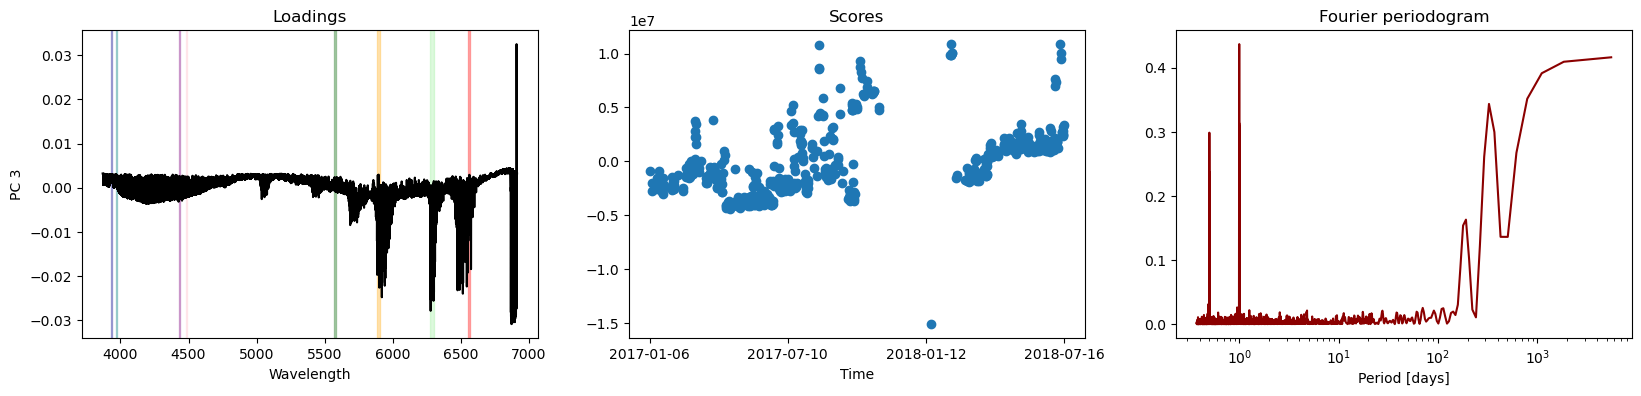

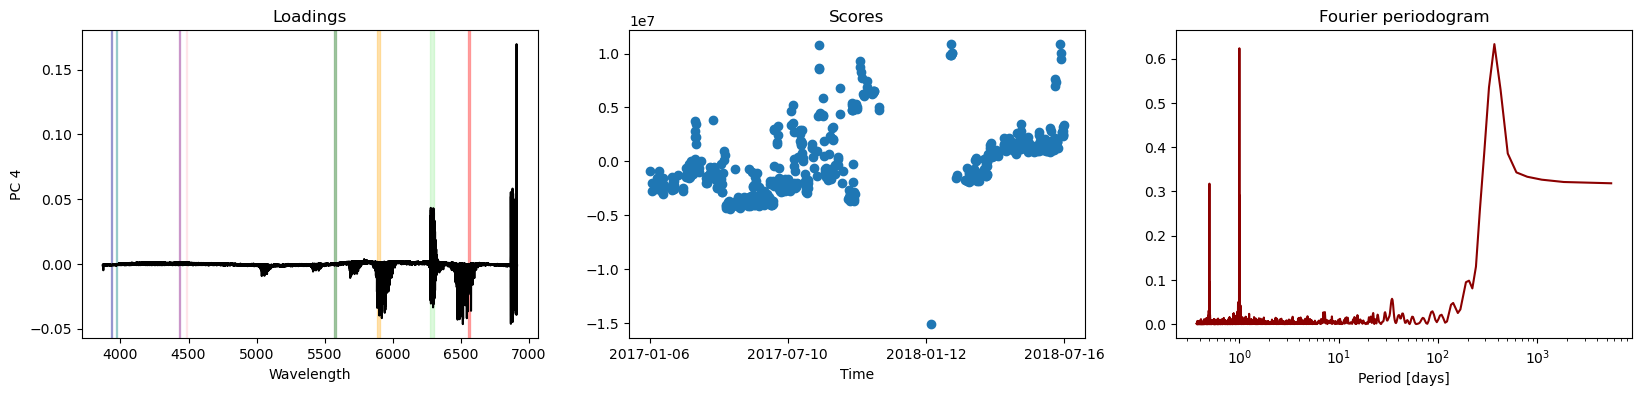

In [79]:
for i in range(n_components // 10):
    fig, axs = plt.subplots(1, 3, figsize=(20, 4))
    
    # Loadings
    axs[0].plot(wl, pca_flux.components_[i], color='k')
    for j in bands:
        axs[0].axvspan(xmin=j['start']*10, xmax=j['end']*10, color=j['color'], label=j['name'], alpha=.3)
    axs[0].set_title('Loadings', size=12)
    axs[0].set_xlabel('Wavelength')
    axs[0].set_ylabel(f'PC {i + 1}')
    
    # Scores
    axs[1].scatter(times, pcs[:, 0])
    axs[1].set_title('Scores', size=12)
    axs[1].set_xlabel('Time')
    axs[1].set_xticks(np.linspace(times[0], times[-1], 4))

    # Fourier periodogram
    axs[2].plot(1 / periodograms[i][0], periodograms[i][1], color='darkred')
    axs[2].set_xscale('log')
    axs[2].set_title('Fourier periodogram', size=12)
    axs[2].set_xlabel('Period [days]')
    
    plt.show()